In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
import matplotlib.pyplot as plt

In [2]:
#Starobinsky potential
V = 'lambda_h*(1 - exp(-sqrt(2/3)*phi) )**2/(4*xi**2)'
param = {'lambda_h' : 0.13, 'xi': 17000}
potential = PotentialFunction.function(V, param_values=param) #Instancia de la clase Potential para el modelo R^2

#Creando instancia de la clase Background. Resuelve automáticamente el sistema dada la condición inicial del inflatón
background = Background(potential, phi0 = 5.7) 
background.solver()


/home/fpineda94/Documentos/Code/primordialpy/src/primordialpy/background.py:56: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(V / kinetic_term)


In [4]:
#Extrayendo datos de la clase background

N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(76.57765776577658)

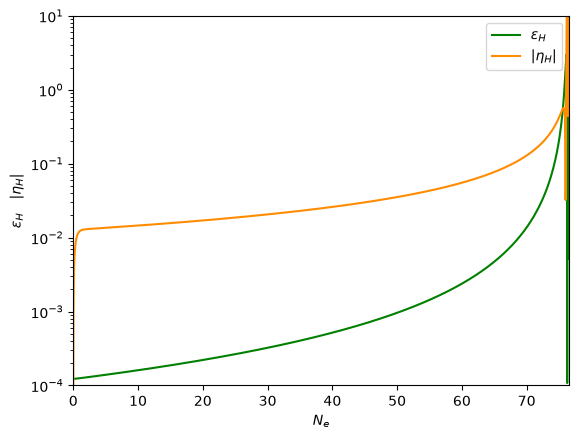

In [5]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')


plt.yscale('log')
plt.ylim(1e-4, 10)

plt.xlim(0, Nend)

plt.xlabel(r'$N_e$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 'best')
#plt.title('Slow-roll parameters')


In [6]:
pert = Perturbations(potential, background, scale= 'CMB', N_CMB = 57.6)
sol = pert.power_spectra_pivot()


Curvature power spectrum at pivot scale is 2.2215426243668856e-09
Tensor to scalar ratio at pivot scale is 0.003333933909079227


In [7]:
PS = pert.power_spectrum()
pert.save_power_spectra(path='./Data')

Computing P(k): 100%|██████████| 1000/1000 [01:36<00:00, 10.40it/s]


Saved to ./Data/power_spectra.dat


In [ ]:
print(pert.spectral_tilts)
